In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# Load data
df = pd.read_csv("run_ww_2019_d.csv")
df = df.drop(columns=["Unnamed: 0"])
df.head()

,datetime,athlete,distance,duration,gender,age_group,country,major
0,2019-01-01,0,0.00,0.00,F,18 - 34,United States,CHICAGO 2019
1,2019-01-01,1,5.27,30.20,M,35 - 54,Germany,BERLIN 2016
2,2019-01-01,2,0.00,0.00,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"
3,2019-01-01,3,10.50,43.95,M,18 - 34,United Kingdom,LONDON 2017
4,2019-01-01,4,9.66,48.65,M,35 - 54,United States,BOSTON 2017


In [3]:
# Clean data
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["distance"] = pd.to_numeric(df["distance"], errors="coerce")
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")

# Drop nan values
df = df.dropna(subset=["datetime", "distance", "duration"])

# Drop 0 values in distance and duration
df = df[(df["distance"] > 0) & (df["duration"] > 0)].copy()

# Sort by time
df = df.sort_values("datetime").reset_index(drop=True)

# Create pace column
df["pace"] = df["duration"] / df["distance"]

# Rearrange columns
df = df[['datetime', 'athlete', 'distance', 'duration', 'pace', 'gender', 'age_group', 'country', 'major']]
df

print("Shape:", df.shape)
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
df.head()

Shape: (4677389, 9)
Date range: 2019-01-01 00:00:00 to 2019-12-31 00:00:00


,datetime,athlete,distance,duration,pace,gender,age_group,country,major
0,2019-01-01,1,5.27,30.200000,5.730550,M,35 - 54,Germany,BERLIN 2016
1,2019-01-01,23918,10.42,51.266667,4.920026,M,35 - 54,United Kingdom,LONDON 2019
2,2019-01-01,23920,8.38,46.616667,5.562848,M,18 - 34,United States,BOSTON 2019
3,2019-01-01,23923,8.01,32.133333,4.011652,M,35 - 54,Brazil,BOSTON 2019
4,2019-01-01,23929,18.25,98.000000,5.369863,M,35 - 54,United Kingdom,"LONDON 2018,LONDON 2019"


In [4]:
# Aggregate daily time series data
daily = (
    df.groupby("datetime")
      .agg(
          total_distance=("distance", "sum"),
          total_duration=("duration", "sum"),
          avg_distance=("distance", "mean"),
          avg_duration=("duration", "mean"),
          avg_pace=("pace", "mean"),
          run_count=("athlete", "count"),
          unique_athletes=("athlete", "nunique")
      )
      .sort_index()
)

print("\nDaily time series shape:", daily.shape)
print(daily.head())


Daily time series shape: (365, 7)
            total_distance  total_duration  avg_distance  avg_duration  \
datetime                                                                 
2019-01-01      145031.969    7.960747e+05     10.600977     58.188340   
2019-01-02      128519.044    6.904677e+05     10.178114     54.681844   
2019-01-03      138475.310    7.431303e+05     10.211290     54.799081   
2019-01-04      110461.981    5.953500e+05     10.069460     54.270738   
2019-01-05      201076.362    1.111063e+06     13.200050     72.937918   

            avg_pace  run_count  unique_athletes  
datetime                                          
2019-01-01  6.128236      13681            13681  
2019-01-02  5.661461      12627            12627  
2019-01-03  5.771389      13561            13561  
2019-01-04  5.844473      10970            10970  
2019-01-05  6.381222      15233            15233  


In [5]:
# Target daily distance frequency
daily_distance = daily["total_distance"].asfreq("D")

# Fill missing days with 0
daily_distance = daily_distance.fillna(0)
daily_distance.head()

datetime
2019-01-01    145031.969
2019-01-02    128519.044
2019-01-03    138475.310
2019-01-04    110461.981
2019-01-05    201076.362
Freq: D, Name: total_distance, dtype: float64

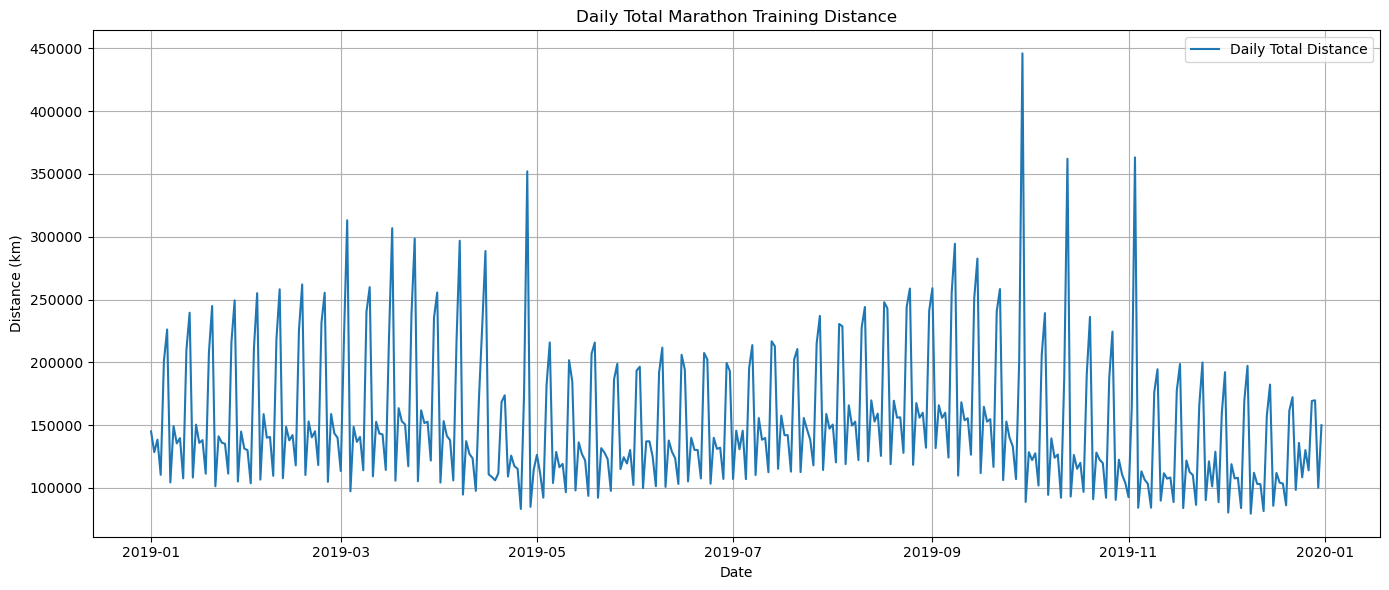

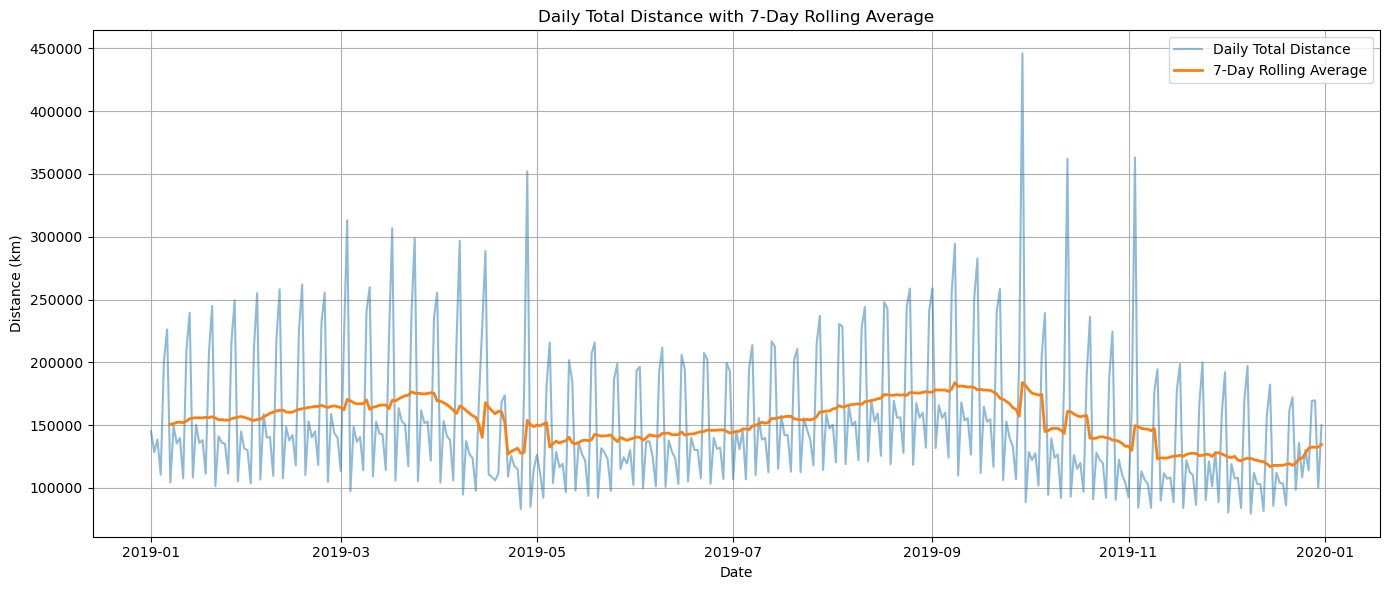

In [6]:
# Plot daily total distances
plt.figure(figsize=(14, 6))
plt.plot(daily_distance, label="Daily Total Distance")
plt.title("Daily Total Marathon Training Distance")
plt.xlabel("Date")
plt.ylabel("Distance (km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 7-day rolling average
rolling_avg = daily_distance.rolling(window=7).mean()
plt.figure(figsize=(14, 6))
plt.plot(daily_distance, alpha=0.5, label="Daily Total Distance")
plt.plot(rolling_avg, linewidth=2, label="7-Day Rolling Average")
plt.title("Daily Total Distance with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Distance (km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

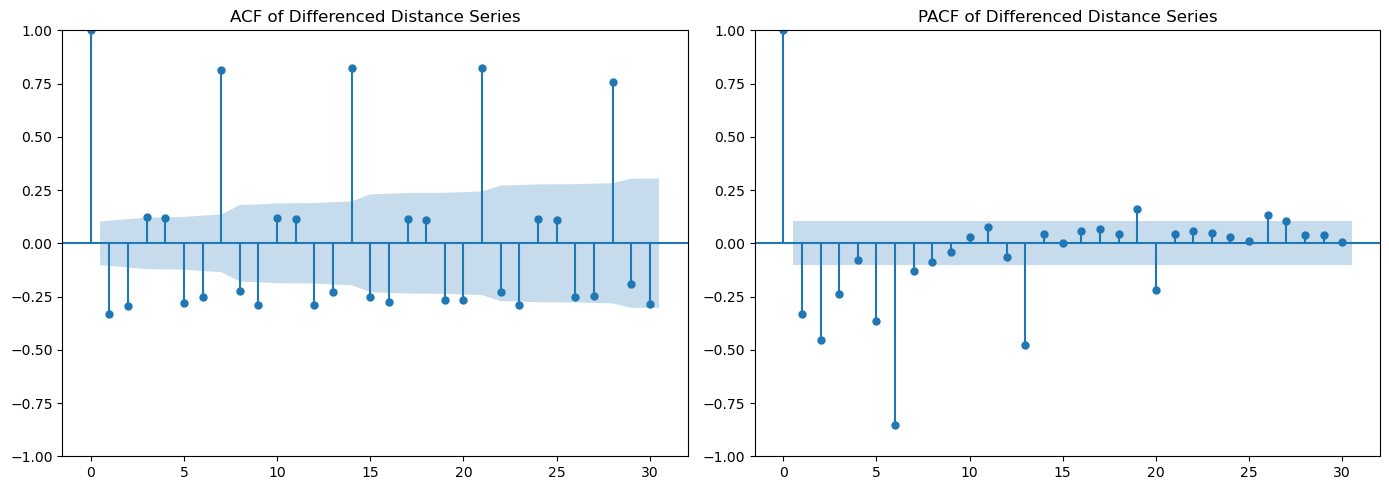

In [7]:
# Difference the data to calculate change
dd_diff = daily_distance.diff().dropna()

# ACF and PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(dd_diff, lags=30, ax=axes[0])
plot_pacf(dd_diff, lags=30, ax=axes[1])
axes[0].set_title("ACF of Differenced Distance Series")
axes[1].set_title("PACF of Differenced Distance Series")
plt.tight_layout()
plt.savefig('fACF_PACF_plots.png',dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Split into training and test sets
# Take instead the first 80% for the training
# Then see if the first 80% of distances can be used to predict the next 20%
train_size = int(len(daily_distance) * 0.8)
train = daily_distance.iloc[:train_size]
test = daily_distance.iloc[train_size:]

print("\nTrain size:", len(train))
print("Test size:", len(test))


Train size: 292
Test size: 73


In [9]:
# Try SARIMAX to account for seasonality
model = SARIMAX(train,
                order=(0,1,1),
                seasonal_order=(1,0,1,7))

fit = model.fit()
forecast = fit.forecast(steps=len(test))
forecast.index = test.index
print("\nSummary:", fit.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.21149D+01    |proj g|=  4.94013D-02

At iterate    5    f=  1.20853D+01    |proj g|=  5.05468D-03

At iterate   10    f=  1.20844D+01    |proj g|=  2.76032D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     11     13      1     0     0   1.262D-05   1.208D+01
  F =   12.084356792710111     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             

Summary:                                      SARIMAX Results        

 This problem is unconstrained.


In [10]:
# Evaluate performance
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 19132.97491584541
RMSE: 27749.220183258254


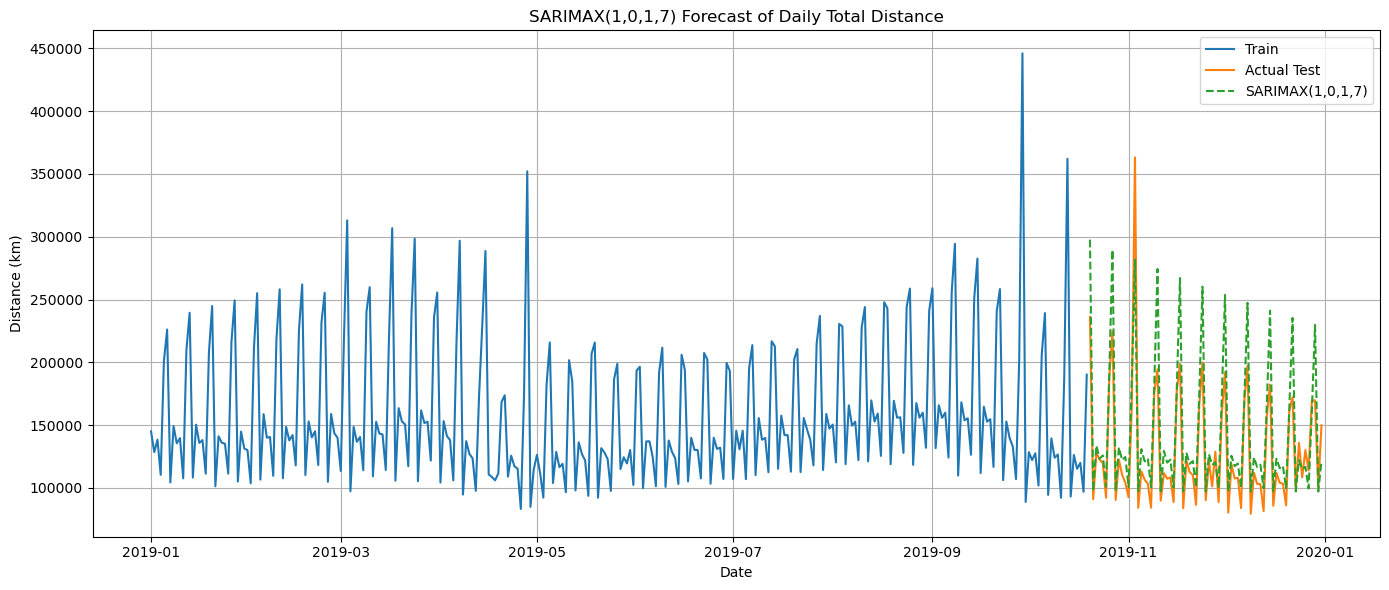

In [11]:
# Plot forecast
plt.figure(figsize=(14, 6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual Test")
plt.plot(forecast, linestyle="--", label="SARIMAX(1,0,1,7)")
plt.title("SARIMAX(1,0,1,7) Forecast of Daily Total Distance")
plt.xlabel("Date")
plt.ylabel("Distance (km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('forecast_daily_total_distance_plot.png',dpi=150, bbox_inches='tight')
plt.show()

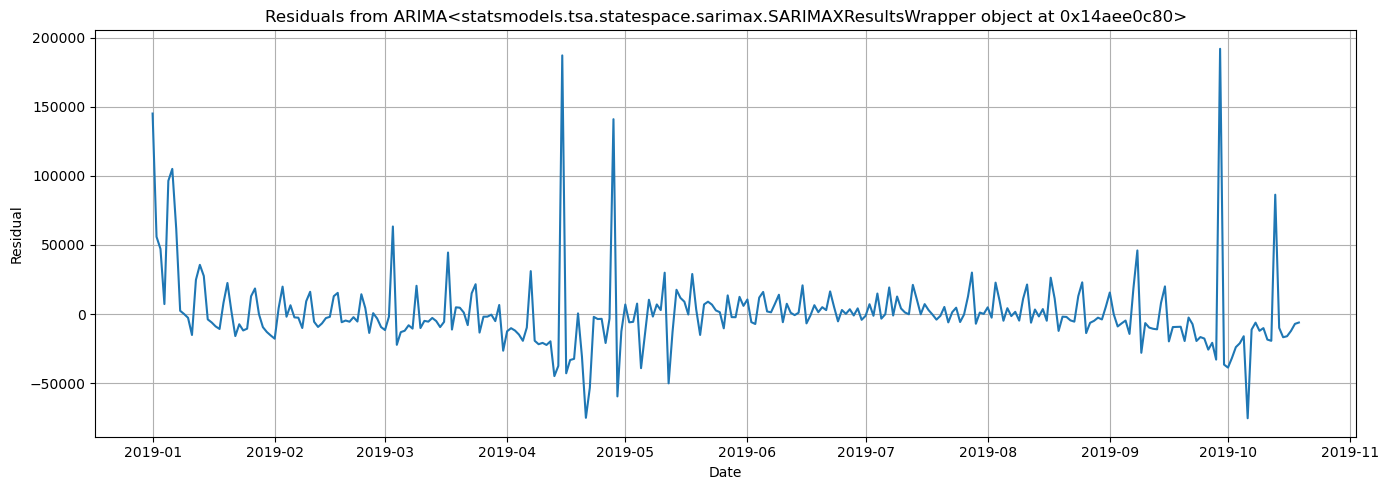

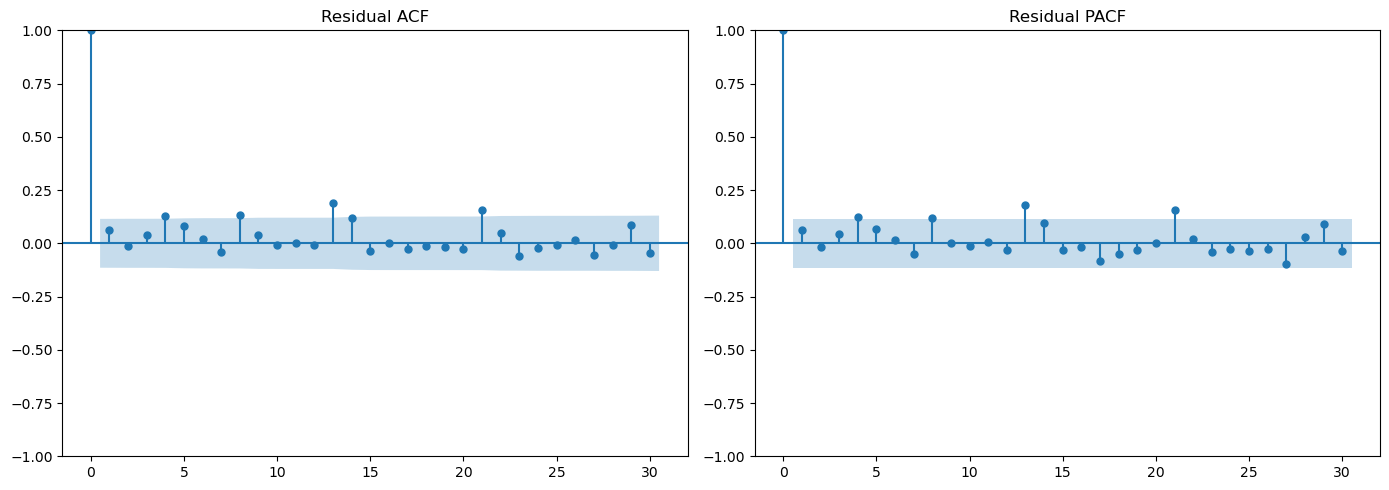


Ljung-Box Test
      lb_stat  lb_pvalue
10  14.935263    0.13444


In [12]:
# Residual Diagnostics
residuals = fit.resid

plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title(f"Residuals from ARIMA{fit}")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(residuals.dropna(), lags=30, ax=axes[0])
plot_pacf(residuals.dropna(), lags=30, ax=axes[1])
axes[0].set_title("Residual ACF")
axes[1].set_title("Residual PACF")
plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
lb_test = acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True)
print("\nLjung-Box Test")
print(lb_test)


In [13]:
# Compare actual vs predicted distances
forecast_df = pd.DataFrame({
    "actual": test,
    "predicted": forecast
})
print("\nForecast vs Actual")
print(forecast_df.head(10))


Forecast vs Actual
                actual      predicted
datetime                             
2019-10-20  236198.478  297663.196224
2019-10-21   91060.299   97487.982834
2019-10-22  128183.957  133781.797347
2019-10-23  122509.080  123313.032220
2019-10-24  119791.111  125889.022411
2019-10-25   92218.025  100947.815558
2019-10-26  187876.508  190088.835305
2019-10-27  224476.617  289548.522370
2019-10-28   90553.864   97448.852065
2019-10-29  122506.260  132278.487983
